In [3]:
# Re-load the file after execution state reset
import pandas as pd

file_path = "earthquase_dataset.csv"
df = pd.read_csv(file_path)

# Display the first few rows to analyze the structure
df.head()


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-01-01T23:50:06.024Z,53.3474,-167.6653,107.310,2.9,ml,18.0,184.0,0.160,0.33,...,2025-01-28T06:18:59.040Z,"92 km ENE of Nikolski, Alaska",earthquake,12.46,7.685,0.105,12.0,reviewed,us,us
1,2025-01-01T23:21:45.743Z,-20.0226,-177.5563,484.253,4.2,mb,13.0,185.0,5.709,0.20,...,2025-01-23T04:28:58.040Z,"267 km WNW of Houma, Tonga",earthquake,26.92,26.905,0.166,10.0,reviewed,us,us
2,2025-01-01T23:07:21.957Z,-2.1566,100.1033,44.253,4.4,mb,33.0,184.0,3.592,0.63,...,2025-01-23T04:15:29.040Z,"58 km ESE of Tuapejat, Indonesia",earthquake,10.09,8.880,0.112,23.0,reviewed,us,us
3,2025-01-01T22:55:44.430Z,-16.9313,167.2988,11.248,4.5,mb,23.0,168.0,1.479,0.88,...,2025-01-23T04:07:48.040Z,"92 km S of Lakatoro, Vanuatu",earthquake,9.75,5.959,0.127,18.0,reviewed,us,us
4,2025-01-01T21:27:41.595Z,-42.4343,-16.0574,10.000,5.2,mb,143.0,36.0,6.085,0.71,...,2025-01-23T03:47:59.040Z,southern Mid-Atlantic Ridge,earthquake,9.79,1.763,0.052,121.0,reviewed,us,us


In [4]:
from datetime import datetime
import numpy as np

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'])

# Sort by time (just in case it's not sorted)
df = df.sort_values(by='time')

# Convert timestamps to relative event times (time since first event in days)
df['time_since_start'] = (df['time'] - df['time'].min()).dt.total_seconds() / (60 * 60 * 24)  # Convert to days

# Extract event times as an array for the Hawkes Process
event_times = df['time_since_start'].values

# Display processed event times
event_times[:10]  # Show first 10 events in days since the first recorded event


array([0.        , 0.02063109, 0.06705646, 0.1141315 , 0.13599763,
       0.14227363, 0.14971012, 0.16407091, 0.16638204, 0.17608343])

[0.         0.55499989 1.10999978 1.66499967 2.21999956 2.77499946
 3.32999935 3.88499924 4.43999913 4.99499902]


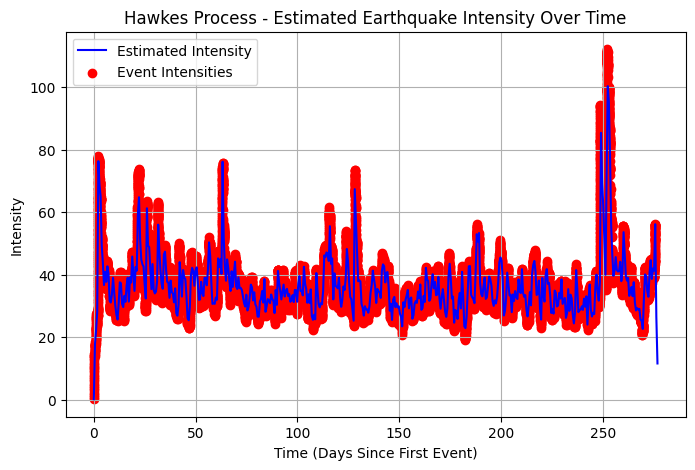

275.9693846105466

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define Hawkes Process parameters
mu = 0.1  # Base intensity (spontaneous event rate)
alpha = 0.8  # Excitation factor (impact of past events)
beta = 1.5  # Decay rate (how fast influence of past events fades)

# Compute intensity function over time
def compute_hawkes_intensity(event_times, mu, alpha, beta, t_values):
    intensities = []
    for t in t_values:
        lambda_t = mu + sum(alpha * np.exp(-beta * (t - t_i)) for t_i in event_times if t_i < t)
        intensities.append(lambda_t)
    return np.array(intensities)

# Define a time grid for visualization
t_values = np.linspace(0, event_times[-1] + 1, 500)  # Time range covering past events
print(t_values[:10])

# Compute intensity function over time
intensity_values = compute_hawkes_intensity(event_times, mu, alpha, beta, t_values)

# Plot the estimated intensity function over time
plt.figure(figsize=(8, 5))
plt.plot(t_values, intensity_values, label="Estimated Intensity", color="blue")

# Plot event times with corresponding intensities
event_intensities = compute_hawkes_intensity(event_times, mu, alpha, beta, event_times)
plt.scatter(event_times, event_intensities, marker='o', color='red', label="Event Intensities")

plt.xlabel("Time (Days Since First Event)")
plt.ylabel("Intensity")
plt.title("Hawkes Process - Estimated Earthquake Intensity Over Time")
plt.legend()
plt.grid(True)
plt.show()

# Predict the next event time based on current intensity
lambda_t = compute_hawkes_intensity(event_times, mu, alpha, beta, [event_times[-1]])[0]
predicted_next_time = event_times[-1] + np.random.exponential(1 / lambda_t)

predicted_next_time


In [5]:
# Group by city
cities = df['place'].unique()

# Dictionary to store models per city
city_models = {}

for city in cities:
    city_df = df[df['place'] == city]  # Filter earthquakes for this city
    event_times = city_df['time_since_start'].values  # Get event times

    if len(event_times) < 50:  # Skip small datasets
        continue

    print(len(event_times), city)
    # Train the Hawkes + NN model for this city (same pipeline as before)
    # city_models[city] = train_hawkes_nn(event_times)  # Define this function


296 south of the Fiji Islands
237 Rat Islands, Aleutian Islands, Alaska
178 Kermadec Islands region
61 Pagan region, Northern Mariana Islands
175 Fiji region
76 Izu Islands, Japan region
113 south of the Kermadec Islands
142 Volcano Islands, Japan region
128 Mid-Indian Ridge
98 Kermadec Islands, New Zealand
52 northern Mid-Atlantic Ridge
61 southeast of the Loyalty Islands
57 7 km SW of Volcano, Hawaii
222 South Sandwich Islands region
58 southern Mid-Atlantic Ridge
148 6 km S of Volcano, Hawaii


In [6]:
# Re-load the file since execution state was reset
import pandas as pd

# Load the uploaded CSV file
file_path = "earthquase_dataset.csv"
df = pd.read_csv(file_path)

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'])

# Sort by time and create a new column with time since first event (in days)
df = df.sort_values(by='time')
df['time_since_start'] = (df['time'] - df['time'].min()).dt.total_seconds() / (60 * 60 * 24)  # Convert to days

# Filter dataset to only include earthquakes in "south of the Fiji Islands"
selected_city = "7 km SW of Volcano, Hawaii"
city_df = df[df['place'] == selected_city].copy()

# Sort by time and extract event times
event_times = city_df['time_since_start'].values

# Display dataset details
num_events = len(event_times)
num_events, event_times[:10]  # Return number of events and first few event times


(57,
 array([ 5.27826491, 24.25855669, 38.02204187, 47.11240229, 47.13527567,
        47.13534257, 47.75949199, 62.87477856, 62.87716583, 62.8864185 ]))

Epoch 0, Loss: 1.0497, Test Loss: 0.9750
Epoch 50, Loss: 0.2814, Test Loss: 1.3109

Final Test RMSE: 0.7204113006591797

Predicted Hawkes Parameters:
  μ (Base Rate): 0.010
  α (Excitation Factor): 3.066
  β (Decay Rate): 0.472

Predicted Next Earthquake Time (Days Since First Event): 266.49766111130543


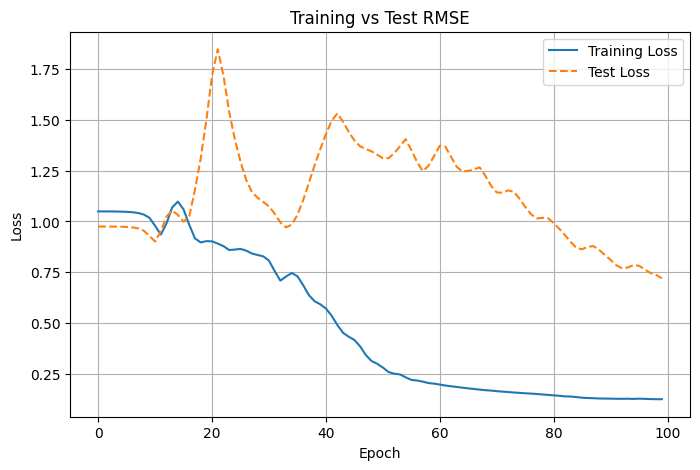

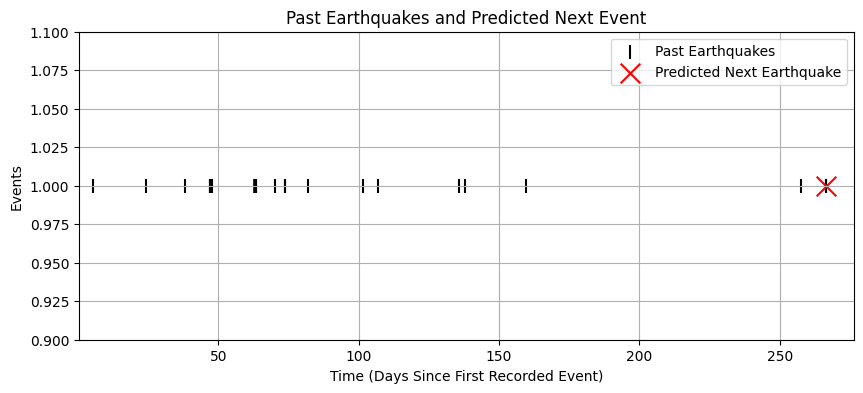

In [77]:
# Re-import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---- Step 1: Prepare Earthquake Data ----

# Use real earthquake dataset (time since first event in days)
event_times = city_df["time_since_start"].values

window_size = 5  # Use last 5 events to estimate Hawkes parameters
X, y = [], []

for i in range(len(event_times) - window_size):
    X.append(event_times[i:i + window_size])  # Input: Last 5 events
    y.append([0.1, 0.8, 1.5])  # Placeholder values (these should be actual estimates!)

X = np.array(X)
y = np.array(y)

# ---- Step 2: Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# ---- Step 3: Define Neural Network for Hawkes Parameter Estimation ----

class HawkesParamNN(nn.Module):
    def __init__(self, input_size=window_size, hidden_size=32, output_size=3):
        super(HawkesParamNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Hidden layer with ReLU
        return torch.nn.functional.softplus(self.fc2(x)) + 0.01  # Prevents zero values

# Initialize model
model = HawkesParamNN()

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---- Step 4: Train the Neural Network ----
epochs = 100
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    
    # Add a penalty to ensure mu > 0
    lambda_mu = 0.1
    mu_pred = predictions[:, 0]
    penalty = lambda_mu * torch.mean(torch.exp(-mu_pred))  # Penalize very small μ
    loss += penalty

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Apply Gradient Clipping
    optimizer.step()
    
    loss_history.append(loss.item())

    # Compute test loss
    with torch.no_grad():
        test_predictions = model(X_test_tensor)
        # test_loss = criterion(test_predictions, y_test_tensor)
        test_loss = torch.sqrt(criterion(test_predictions, y_test_tensor))  # Convert MSE to RMSE
        test_loss_history.append(test_loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

# ---- Step 5: Evaluate Model on Test Data ----
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    # test_loss = criterion(test_predictions, y_test_tensor)
    test_loss = torch.sqrt(criterion(test_predictions, y_test_tensor))  # Convert MSE to RMSE
    print("\nFinal Test RMSE:", test_loss.item())

# ---- Step 6: Predict Hawkes Parameters for New Data ----

# Use last 5 earthquakes to predict Hawkes parameters
test_input = torch.tensor(event_times[-window_size:], dtype=torch.float32).view(1, -1)
predicted_params = model(test_input).detach().numpy().flatten()

mu_pred, alpha_pred, beta_pred = predicted_params
print("\nPredicted Hawkes Parameters:")
print(f"  μ (Base Rate): {mu_pred:.3f}")
print(f"  α (Excitation Factor): {alpha_pred:.3f}")
print(f"  β (Decay Rate): {beta_pred:.3f}")

# ---- Step 7: Use Hawkes Process to Predict Next Event ----

def compute_hawkes_intensity(event_times, mu, alpha, beta, t_values):
    intensities = []
    for t in t_values:
        lambda_t = mu + sum(alpha * np.exp(-beta * (t - t_i)) for t_i in event_times if t_i < t)
        intensities.append(lambda_t)
    return np.array(intensities)

# Predict next event time using NN-estimated parameters
lambda_t = compute_hawkes_intensity(event_times, mu_pred, alpha_pred, beta_pred, [event_times[-1]])[0]
predicted_next_event = event_times[-1] + np.random.exponential(1 / lambda_t)

print("\nPredicted Next Earthquake Time (Days Since First Event):", predicted_next_event)

# ---- Step 8: Visualize Training and Test Loss ----

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Training Loss")
plt.plot(test_loss_history, label="Test Loss", linestyle='dashed')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test RMSE")
plt.legend()
plt.grid(True)
plt.show()

# ---- Step 9: Visualize Past Events and Predicted Next Event ----

plt.figure(figsize=(10, 4))
plt.scatter(event_times, np.ones_like(event_times), marker='|', color='black', s=100, label="Past Earthquakes")
plt.scatter(predicted_next_event, 1, marker='x', color='red', s=200, label="Predicted Next Earthquake")
plt.xlabel("Time (Days Since First Recorded Event)")
plt.ylabel("Events")
plt.title("Past Earthquakes and Predicted Next Event")
plt.xlim(min(event_times) - 5, max(event_times) + 10)
plt.ylim(0.9, 1.1)
plt.legend()
plt.grid(True)
plt.show()



Epoch 0, Loss: 352.9994, Test Loss: 15.4414, Next Event Loss: 4.9340
Epoch 50, Loss: 1.6078, Test Loss: 0.9765, Next Event Loss: 5.7986
Epoch 100, Loss: 1.0094, Test Loss: 0.5738, Next Event Loss: 6.2744
Epoch 150, Loss: 0.9922, Test Loss: 0.5989, Next Event Loss: 6.1172
Epoch 200, Loss: 0.8089, Test Loss: 0.5687, Next Event Loss: 4.6763
Epoch 250, Loss: 0.9103, Test Loss: 0.5826, Next Event Loss: 5.5545
Epoch 300, Loss: 0.8926, Test Loss: 0.5825, Next Event Loss: 5.4709
Epoch 350, Loss: 2.4890, Test Loss: 0.5325, Next Event Loss: 22.0782
Epoch 400, Loss: 0.9928, Test Loss: 0.5523, Next Event Loss: 6.9238
Epoch 450, Loss: 0.7870, Test Loss: 0.5614, Next Event Loss: 4.7790
Epoch 500, Loss: 0.7292, Test Loss: 0.5575, Next Event Loss: 4.1668
Epoch 550, Loss: 1.1589, Test Loss: 0.5037, Next Event Loss: 8.8294
Epoch 600, Loss: 0.5918, Test Loss: 0.4113, Next Event Loss: 4.2950
Epoch 650, Loss: 0.9696, Test Loss: 0.3492, Next Event Loss: 8.4574
Epoch 700, Loss: 0.4578, Test Loss: 0.2962, Nex

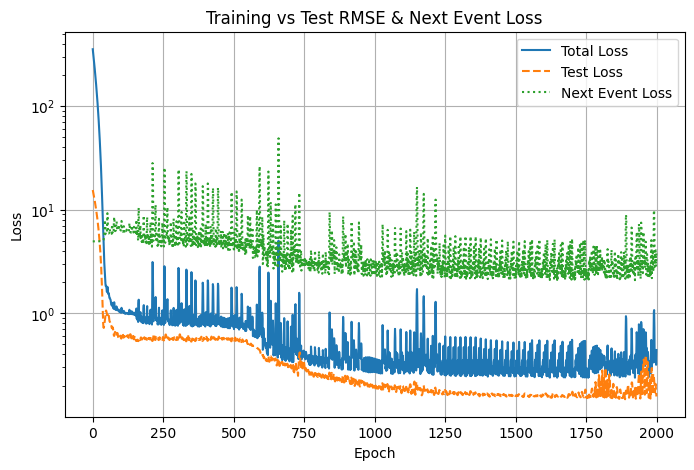

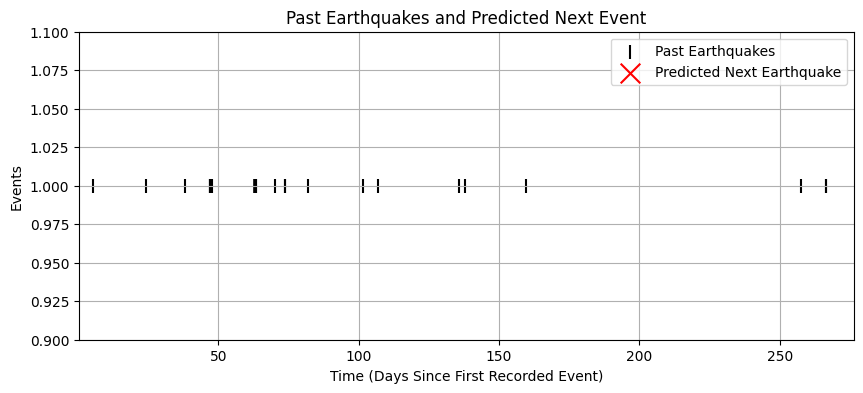

In [13]:
# Re-import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---- Step 1: Prepare Earthquake Data ----

# Use real earthquake dataset (time since first event in days)
event_times = city_df["time_since_start"].values

window_size = 5  # Use last 5 events to estimate Hawkes parameters
X, y, next_events = [], [], []

for i in range(len(event_times) - window_size - 1):
    X.append(event_times[i:i + window_size])  # Input: Last 5 events
    y.append([0.1, 0.8, 1.5])  # Placeholder values (these should be actual estimates!)
    next_events.append(event_times[i + window_size])  # Store the real next event time

X = np.array(X)
y = np.array(y)
next_events = np.array(next_events)  # Convert next event times to NumPy array

# ---- Step 2: Train/Test Split ----
X_train, X_test, y_train, y_test, next_train, next_test = train_test_split(
    X, y, next_events, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
next_train_tensor = torch.tensor(next_train, dtype=torch.float32)
next_test_tensor = torch.tensor(next_test, dtype=torch.float32)

# ---- Step 3: Define Neural Network for Hawkes Parameter Estimation ----

class HawkesParamNN(nn.Module):
    def __init__(self, input_size=window_size, hidden_size=32, output_size=3):
        super(HawkesParamNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Hidden layer with ReLU
        return torch.nn.functional.softplus(self.fc2(x)) + 0.01  # Prevents zero values

# Initialize model
model = HawkesParamNN()

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---- Step 4: Train the Neural Network ----
epochs = 2000
loss_history = []
test_loss_history = []
next_event_loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_train_tensor)  # Predict Hawkes parameters
    loss = criterion(predictions, y_train_tensor)  # MSE loss for parameter estimation

    # Extract predicted Hawkes parameters
    mu_pred = predictions[:, 0]
    alpha_pred = predictions[:, 1]
    beta_pred = predictions[:, 2]

    # Compute next event prediction
    lambda_t = mu_pred + torch.sum(alpha_pred.unsqueeze(1) *
                                   torch.exp(-beta_pred.unsqueeze(1) *
                                             (X_train_tensor[:, -1].unsqueeze(1) - X_train_tensor)), dim=1)

    predicted_next_event = X_train_tensor[:, -1] + torch.exp(torch.tensor(1.0) / lambda_t)

    # Compute absolute error between predicted and real next event time
    next_event_loss = torch.mean(torch.abs(predicted_next_event - next_train_tensor))

    # Combine losses: Parameter loss + Next event prediction validation
    total_loss = loss + 0.1 * next_event_loss

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevents exploding gradients
    optimizer.step()

    loss_history.append(total_loss.item())
    next_event_loss_history.append(next_event_loss.item())

    # Compute test loss
    with torch.no_grad():
        test_predictions = model(X_test_tensor)
        test_loss = torch.sqrt(criterion(test_predictions, y_test_tensor))  # Convert MSE to RMSE
        test_loss_history.append(test_loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, Next Event Loss: {next_event_loss.item():.4f}")

# ---- Step 5: Evaluate Model on Test Data ----
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = torch.sqrt(criterion(test_predictions, y_test_tensor))  # RMSE
    print("\nFinal Test RMSE:", test_loss.item())

# ---- Step 6: Predict Hawkes Parameters for New Data ----

# Use last 5 earthquakes to predict Hawkes parameters
test_input = torch.tensor(event_times[-window_size:], dtype=torch.float32).view(1, -1)
predicted_params = model(test_input).detach().numpy().flatten()

mu_pred, alpha_pred, beta_pred = predicted_params
print("\nPredicted Hawkes Parameters:")
print(f"  μ (Base Rate): {mu_pred:.3f}")
print(f"  α (Excitation Factor): {alpha_pred:.3f}")
print(f"  β (Decay Rate): {beta_pred:.3f}")

# ---- Step 7: Use Hawkes Process to Predict Next Event ----

def compute_hawkes_intensity(event_times, mu, alpha, beta, t_values):
    intensities = []
    for t in t_values:
        lambda_t = mu + sum(alpha * np.exp(-beta * (t - t_i)) for t_i in event_times if t_i < t)
        intensities.append(lambda_t)
    return np.array(intensities)

# Predict next event time using NN-estimated parameters
lambda_t = compute_hawkes_intensity(event_times, mu_pred, alpha_pred, beta_pred, [event_times[-1]])[0]
predicted_next_event = event_times[-1] + np.random.exponential(1 / lambda_t)

print("\nPredicted Next Earthquake Time (Days Since First Event):", predicted_next_event)

# ---- Step 8: Visualize Training and Test Loss ----

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Total Loss")
plt.plot(test_loss_history, label="Test Loss", linestyle='dashed')
plt.plot(next_event_loss_history, label="Next Event Loss", linestyle='dotted')
plt.yscale('log')  # Apply log scale to y-axis
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test RMSE & Next Event Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Step 9: Visualize Past Events and Predicted Next Event ----

plt.figure(figsize=(10, 4))
plt.scatter(event_times, np.ones_like(event_times), marker='|', color='black', s=100, label="Past Earthquakes")
plt.scatter(predicted_next_event, 1, marker='x', color='red', s=200, label="Predicted Next Earthquake")
plt.xlabel("Time (Days Since First Recorded Event)")
plt.ylabel("Events")
plt.title("Past Earthquakes and Predicted Next Event")
plt.xlim(min(event_times) - 5, max(event_times) + 10)
plt.ylim(0.9, 1.1)
plt.legend()
plt.grid(True)
plt.show()
